## **Messwerte:**

In [31]:
import numpy as np
import matplotlib.pyplot as plt
#Messwerte für die Maximalkraft in N
                                                  #Konzentration Tensidlösung
Messwerte = np.array([[0.074, 0.074, 0.074, 0.074, 0.073],  #0 mmol/l

                      [0.072, 0.073, 0.073, 0.073, 0.072],  # 8 mmol/l

                      [0.074, 0.074, 0.074, 0.074, 0.074],  # 4 mmol/l

                      [0.074, 0.074, 0.074, 0.075, 0.074],  # 2 mmol/l

                      [0.074, 0.075, 0.075, 0.074, 0.075],  # 1 mmol/l

                      [0.074, 0.074, 0.074, 0.074, 0.074],  # 0.5 mmol/l

                      [0.075, 0.074, 0.075, 0.075, 0.075]  # 0.25 mmol/l
                     ])

Konzentration = np.array([0, 8, 4, 2,1, 0.5, 0.25]) #Konzentrationen in mmol/l

Mittelwerte = np.mean(Messwerte, axis = 1) #Einzelne Mittelwerte über die 5 Messungen
MittelwertFehler = Mittelwerte * 1/100 #Konstanter Fehler in der Messung von 1 %

#Messwerte für Tensid
Molekulargewicht = 56.44 #Molekulargewicht in g/mol
Zugabemenge = 0.187 #Zugabemenge in g

#Messwerte für Flüssigkeit und Ring
Temp = 20.02 #Grad Celsius

Durchmesser = 5.83e-3 #Durchmesserin m
D_Fehler = 0.05e-3 #Fehler des Durchmessers in m


#Mittelwert für die Oberflächenspannung
Oberflaechenspannnung = Mittelwerte / (4 * np.pi *(Durchmesser/2))


## **Fehlerbehandlung:**

In [32]:
#Fehlerbestimmung für die Oberflächenspannung durch Gaußsche Fehlerfortpflanzung
from Skripte.Fehlerfortpflanzung import Gaußfehler
import sympy

F, r = sympy.symbols("F, r")
Variablen = np.array([F,r])
expr = F / (4*np.pi*r)

FehlerObSp = np.array([]) #Berechnete Fehler für die Oberflächenspannung für die einzelnen Messreihen

for pos in range(len(Mittelwerte)):
    mean = Mittelwerte[pos]
    err = MittelwertFehler[pos]
    FehlerObSp = np.append(FehlerObSp, Gaußfehler(expr, Variablen, np.array([mean, Durchmesser/2]), np.array([err, D_Fehler]))) #Gaußfehler für die aktuelle Messreihe

print(FehlerObSp)

[0.04000127 0.03935084 0.04010968 0.04021808 0.04043489 0.04010968
 0.04054329]


## **Grafische Darstellung:**

Text(0.5, 1.0, 'Oberflächenspannung der Lösung')

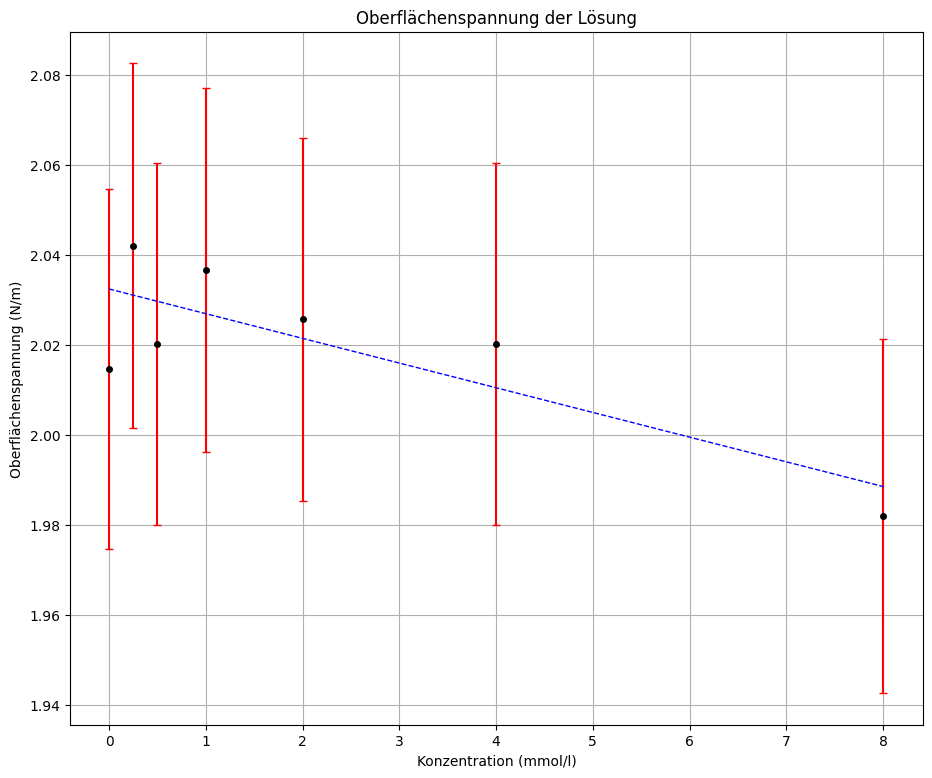

In [36]:
#Grafische Darstellung
import scipy
import numpy as np

def f(x,k,c):
    return k*x +c

coefficients , pcov = scipy.optimize.curve_fit(f, Konzentration, Oberflaechenspannnung, sigma = FehlerObSp, absolute_sigma = True)
a = coefficients[0]
c = coefficients[1]

fig, ax1 = plt.subplots(1,1, figsize = (11,9))

ax1.errorbar(Konzentration, Oberflaechenspannnung, yerr = FehlerObSp , fmt = "o", label = "Datensatz", color = "black", markersize  = 4 , capsize = 3, ecolor = "r")
xvalues = np.linspace(0, np.max(Konzentration)+0.01, num = 100)
ax1.plot(xvalues, a * xvalues +c , "--", color = "blue", linewidth = 1)

ax1.set_xlabel("Konzentration (mmol/l)")
ax1.set_ylabel("Oberflächenspannung (N/m)")

ax1.grid(True)
ax1.set_title("Oberflächenspannung der Lösung")
